# Schritt 1: Titel & Zielsetzung
# CNN für CIFAR-10: Dropout und BatchNormalization

In diesem Notebook untersuchen wir ein Convolutional Neural Network (CNN) für den CIFAR-10-Datensatz.

## Ziel

Wir analysieren gezielt den Einfluss von:

- Dropout (Regularisierung)
- BatchNormalization (stabileres Training)

## Leitfragen

- Wie verändert Dropout die Lernkurven?
- Wie beeinflusst BatchNormalization die Konvergenzgeschwindigkeit?
- Welche Klassen werden am häufigsten verwechselt?

# Schritt 2: GPU-Hinweis (wichtig für CIFAR-10)
## Hinweis zur Laufzeit (Google Colab)

Für dieses Notebook wird ein GPU-Beschleuniger empfohlen:

Runtime → Hardwarebeschleuniger → GPU

Ohne GPU kann das Training deutlich länger dauern.

# Schritt 3: Bibliotheken

In [1]:
# ── Erste Zelle im Notebook ──
import time
notebook_start = time.time()
print("Notebook gestartet.")

Notebook gestartet.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random

# Seeds ganz am Anfang setzen
SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Schritt 4: CIFAR-10 laden
## CIFAR-10-Datensatz

- 60.000 Bilder (32×32, RGB)
- 10 Klassen (z. B. Flugzeug, Auto, Katze, Hund)
- deutlich komplexer als Fashion-MNIST

In [3]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Trainingsdaten:", X_train_full.shape)
print("Testdaten:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Trainingsdaten: (50000, 32, 32, 3)
Testdaten: (10000, 32, 32, 3)


# Schritt 5: Klassennamen

In [4]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Schritt 6: Bilder anzeigen

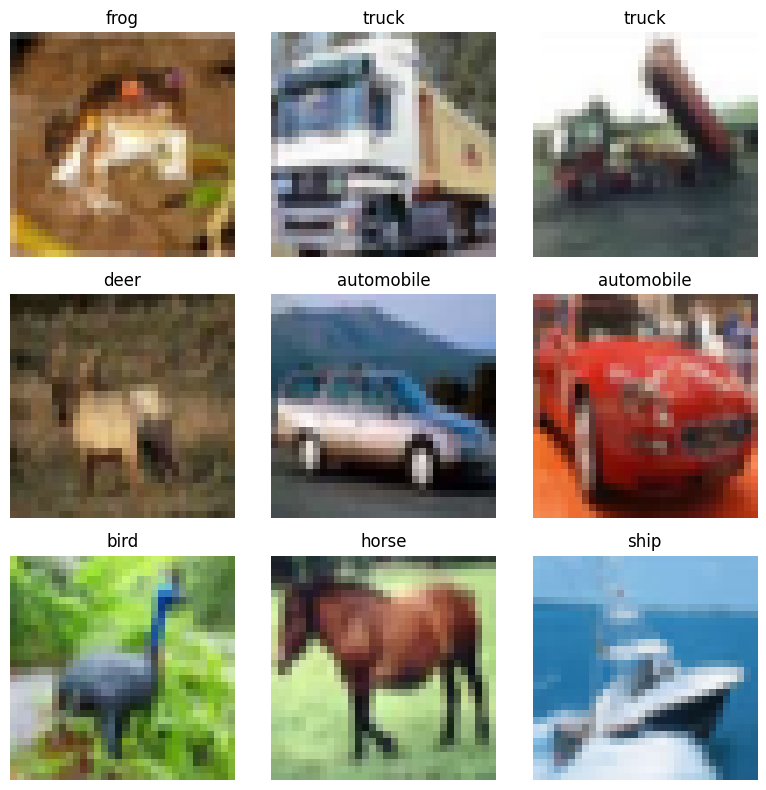

In [5]:
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train_full[i])
    plt.title(class_names[y_train_full[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Schritt 7: Normalisierung + Validation Split

In [6]:
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=5000, random_state=SEED
)

# Hyperparameter festlegen

In [7]:
input_patience = 3
input_epochs = 50

# Schritt 8: Basismodell (ohne Dropout, ohne BatchNorm)
## Basismodell

Ein einfaches CNN ohne Dropout und ohne BatchNormalization.

In [8]:
def build_base_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),

        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Schritt 9: Kompilieren + Early Stopping

In [9]:
def make_early_stop():
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=input_patience,
        restore_best_weights=True
    )

In [10]:
model_base = build_base_model()

model_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Schritt 10: Training Basismodell

In [11]:
history_base = model_base.fit(
    X_train, y_train,
    epochs=input_epochs,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    batch_size=32,
    verbose=1
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.4609 - loss: 1.4859 - val_accuracy: 0.5794 - val_loss: 1.1560
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6237 - loss: 1.0695 - val_accuracy: 0.6522 - val_loss: 0.9739
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6915 - loss: 0.8783 - val_accuracy: 0.6978 - val_loss: 0.8523
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7376 - loss: 0.7494 - val_accuracy: 0.7068 - val_loss: 0.8593
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7722 - loss: 0.6508 - val_accuracy: 0.7122 - val_loss: 0.8570
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7984 - loss: 0.5749 - val_accuracy: 0.7034 - val_loss: 0.9097


# Schritt 11: Dropout-Modell
## Modell mit Dropout

Dropout reduziert Overfitting, indem zufällig Neuronen deaktiviert werden.

In [12]:
def build_dropout_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),

        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.20),

        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.20),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [13]:
model_dropout = build_dropout_model()

model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=input_epochs,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    batch_size=32,
    verbose=1
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.4158 - loss: 1.5961 - val_accuracy: 0.5520 - val_loss: 1.2275
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5685 - loss: 1.2164 - val_accuracy: 0.6290 - val_loss: 1.0300
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6241 - loss: 1.0650 - val_accuracy: 0.6672 - val_loss: 0.9381
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6586 - loss: 0.9723 - val_accuracy: 0.6936 - val_loss: 0.8621
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6841 - loss: 0.8985 - val_accuracy: 0.7188 - val_loss: 0.7892
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7040 - loss: 0.8480 - val_accuracy: 0.7252 - val_loss: 0.7692
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7175 - loss: 0.8001 - val_accuracy: 0.7388 - val_loss: 0.7500
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7326 - loss: 0.7624 -

# Schritt 12: BatchNorm-Modell
## Modell mit BatchNormalization

BatchNormalization stabilisiert und beschleunigt das Training.

In [14]:
def build_bn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),

        tf.keras.layers.Conv2D(32, 3),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),

        tf.keras.layers.Conv2D(32, 3),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),

        tf.keras.layers.Conv2D(64, 3),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),

        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [15]:
model_bn = build_bn_model()

model_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = model_bn.fit(
    X_train, y_train,
    epochs=input_epochs,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    batch_size=32,
    verbose=1
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5417 - loss: 1.2850 - val_accuracy: 0.5768 - val_loss: 1.1579
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6904 - loss: 0.8839 - val_accuracy: 0.5684 - val_loss: 1.3226
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7426 - loss: 0.7368 - val_accuracy: 0.5592 - val_loss: 1.3712
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7792 - loss: 0.6347 - val_accuracy: 0.5986 - val_loss: 1.2785


# Schritt 13: Lernkurven vergleichen

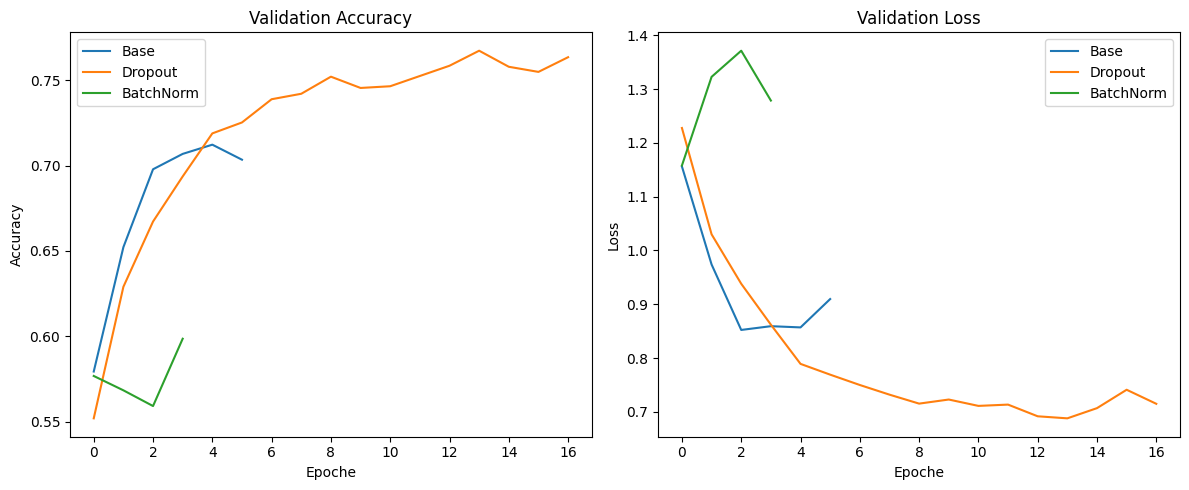

In [16]:
plt.figure(figsize=(12, 5))

# Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_base.history['val_accuracy'], label='Base')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout')
plt.plot(history_bn.history['val_accuracy'], label='BatchNorm')
plt.title("Validation Accuracy")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.legend()

# Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history_base.history['val_loss'], label='Base')
plt.plot(history_dropout.history['val_loss'], label='Dropout')
plt.plot(history_bn.history['val_loss'], label='BatchNorm')
plt.title("Validation Loss")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Schritt 14: Test-Accuracy vergleichen

In [17]:
acc_base = model_base.evaluate(X_test, y_test, verbose=0)[1]
acc_dropout = model_dropout.evaluate(X_test, y_test, verbose=0)[1]
acc_bn = model_bn.evaluate(X_test, y_test, verbose=0)[1]

print("Base:", acc_base)
print("Dropout:", acc_dropout)
print("BatchNorm:", acc_bn)

Base: 0.6987000107765198
Dropout: 0.7560999989509583
BatchNorm: 0.5910000205039978


# Schritt 15: Konfusionsmatrix

In [18]:
models = {
    "Base": model_base,
    "Dropout": model_dropout,
    "BatchNorm": model_bn
}

accuracies = {
    "Base": acc_base,
    "Dropout": acc_dropout,
    "BatchNorm": acc_bn
}

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print("Bestes Modell:", best_model_name)

Bestes Modell: Dropout


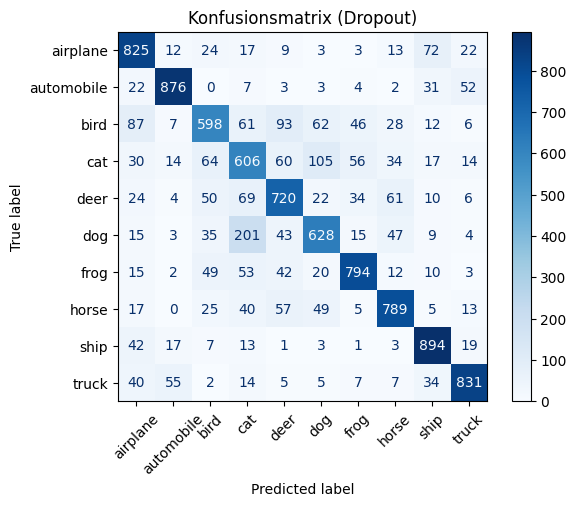

In [19]:
y_pred = best_model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title(f"Konfusionsmatrix ({best_model_name})")
plt.show()

# Schritt 16: Interpretation (wichtig!)
## Interpretation

Wichtiger technischer Hinweis:
Für jedes Modell muss ein eigener EarlyStopping-Callback verwendet werden.
Wird derselbe Callback mehrfach wiederverwendet, können spätere Modelle zu früh stoppen.

### Beobachtungen

- Das Basismodell liefert eine sinnvolle Referenz
- Dropout kann Overfitting reduzieren, darf aber nicht zu stark gewählt werden
- BatchNormalization verbessert häufig die Trainingsstabilität und beschleunigt die Konvergenz

### Typische Verwechslungen in CIFAR-10

- cat ↔ dog
- deer ↔ horse
- automobile ↔ truck

## Fazit

Dropout und BatchNormalization sind hilfreiche Bausteine für CNNs,
müssen aber sauber implementiert und fair verglichen werden.

In [20]:
# ── Letzte Zelle im Notebook ──
total = time.time() - notebook_start
minuten = int(total // 60)
sekunden = int(total % 60)
print(f"Gesamtlaufzeit: {minuten} min {sekunden} sek")

Gesamtlaufzeit: 4 min 27 sek
